# 10 — AIA Fold-2015 Image Baseline Comparison

This CPU-only notebook compares the fold-2015 image-only benchmarks:

1. **05 AlexNet pilot** — capped pilot benchmark.
2. **06B AlexNet largecap** — larger capped benchmark.
3. **08B AlexNet-v2 physics-safe largecap** — stricter preprocessing and physics-safe rules.
4. **09 ResNet18 physics-safe full-natural** — full natural class distribution benchmark.

The main rule is simple: **official test metrics must use the validation-selected threshold**. Any test-selected best threshold is diagnostic only.

In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = str

def repo_root() -> Path:
    import subprocess
    try:
        return Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
    except Exception:
        return Path.cwd()

ROOT = repo_root()
METRICS_DIR = ROOT / "results" / "metrics"
FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Metrics dir:", METRICS_DIR)

Repo root: /home/abmoses2000/solar_flare_aia
Metrics dir: /home/abmoses2000/solar_flare_aia/results/metrics


In [2]:
def first_existing(patterns):
    matches = []
    for pat in patterns:
        matches.extend(sorted(METRICS_DIR.glob(pat)))
    seen = set()
    unique = []
    for p in matches:
        if p not in seen:
            seen.add(p)
            unique.append(p)
    return unique[0] if unique else None

def safe_get(d, keys, default=np.nan):
    cur = d
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

def extract_json_row(name, run_type, path):
    with open(path) as f:
        m = json.load(f)
    test = m.get("test", {})
    official = test.get("at_selected_threshold", {}) or {}
    data_summary = m.get("data_summary", [])

    train_rows = val_rows = test_rows = test_pos = test_neg = np.nan
    for row in data_summary:
        split = str(row.get("split", "")).lower()
        if split == "train":
            train_rows = row.get("rows", np.nan)
        elif split in ("val", "validation"):
            val_rows = row.get("rows", np.nan)
        elif split == "test":
            test_rows = row.get("rows", np.nan)
            test_pos = row.get("positives", np.nan)
            test_neg = row.get("negatives", np.nan)

    return {
        "run": name,
        "run_type": run_type,
        "source_file": str(path.relative_to(ROOT)),
        "train_rows": train_rows,
        "val_rows": val_rows,
        "test_rows": test_rows,
        "test_positives": test_pos,
        "test_negatives": test_neg,
        "best_epoch": m.get("best_epoch", np.nan),
        "threshold_protocol": "validation-selected max-TSS",
        "threshold": safe_get(m, ["selected_threshold_from_validation"], official.get("threshold", np.nan)),
        "roc_auc": test.get("roc_auc", np.nan),
        "pr_auc": test.get("pr_auc", np.nan),
        "brier_score": test.get("brier_score", np.nan),
        "accuracy": official.get("accuracy", np.nan),
        "precision": official.get("precision", np.nan),
        "recall": official.get("recall", np.nan),
        "specificity": official.get("specificity", np.nan),
        "f1": official.get("f1", np.nan),
        "tss": official.get("tss", np.nan),
        "hss": official.get("hss", np.nan),
        "tp": official.get("tp", np.nan),
        "tn": official.get("tn", np.nan),
        "fp": official.get("fp", np.nan),
        "fn": official.get("fn", np.nan),
        "diagnostic_test_best_tss": safe_get(m, ["test", "best_tss", "tss"], np.nan),
        "notes": "",
    }

def fallback_row(name, run_type, source_hint, **values):
    base = {
        "run": name,
        "run_type": run_type,
        "source_file": source_hint,
        "train_rows": np.nan,
        "val_rows": np.nan,
        "test_rows": np.nan,
        "test_positives": np.nan,
        "test_negatives": np.nan,
        "best_epoch": np.nan,
        "threshold_protocol": "validation-selected max-TSS",
        "threshold": np.nan,
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "brier_score": np.nan,
        "accuracy": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "specificity": np.nan,
        "f1": np.nan,
        "tss": np.nan,
        "hss": np.nan,
        "tp": np.nan,
        "tn": np.nan,
        "fp": np.nan,
        "fn": np.nan,
        "diagnostic_test_best_tss": np.nan,
        "notes": "Fallback values from project record; JSON file should be preferred when available.",
    }
    base.update(values)
    return base

## Locate available metric JSON files

In [3]:
found = {
    "05": first_existing(["*alexnet*fold2015*pilot*metrics.json", "*fold2015*pilot*metrics.json"]),
    "06b": first_existing(["*alexnet*fold2015*largecap*metrics.json", "*largecap_benchmark*metrics.json"]),
    "08b": first_existing(["aia_alexnet_v2_physics_safe_fold2015_largecap_benchmark_largecap_v2_physics_safe_metrics.json", "*alexnet_v2*physics_safe*metrics.json"]),
    "09": first_existing(["aia_resnet18_physics_safe_fold2015_fullnatural_benchmark_fullnatural_physics_safe_metrics.json", "*resnet18*fullnatural*physics_safe_metrics.json"]),
}
display(pd.DataFrame([{"run_key": k, "path": str(v.relative_to(ROOT)) if v else None} for k, v in found.items()]))

,run_key,path
0,05,results/metrics/aia_alexnet_fold2015_benchmark...
1,06b,results/metrics/aia_alexnet_fold2015_largecap_...
2,08b,results/metrics/aia_alexnet_v2_physics_safe_fo...
3,09,results/metrics/aia_resnet18_physics_safe_fold...


## Build comparison table

In [4]:
rows = []

if found["05"]:
    rows.append(extract_json_row("05 AlexNet pilot", "capped pilot", found["05"]))
else:
    rows.append(fallback_row(
        "05 AlexNet pilot", "capped pilot", "manual fallback from project record",
        test_rows=3300, test_positives=300, test_negatives=3000, threshold=0.91,
        roc_auc=0.7252711111, pr_auc=0.1912054437, brier_score=0.5779051525,
        accuracy=0.6354545455, precision=0.1534919417, recall=0.6666666667,
        specificity=0.6323333333, f1=0.2495321273, tss=0.299, hss=0.1193851068,
        tp=200, tn=1897, fp=1103, fn=100, diagnostic_test_best_tss=0.324333
    ))

if found["06b"]:
    rows.append(extract_json_row("06B AlexNet largecap", "capped largecap", found["06b"]))
else:
    rows.append(fallback_row(
        "06B AlexNet largecap", "capped largecap", "manual fallback from project record",
        train_rows=11230, val_rows=5629, test_rows=5531, test_positives=531, test_negatives=5000,
        best_epoch=1, threshold=0.6975, roc_auc=0.6790623352, pr_auc=0.2117349295,
        brier_score=0.3859039352, accuracy=0.5384198156, precision=0.1280353201,
        recall=0.6553672316, specificity=0.526, f1=0.2142197599, tss=0.1813672316,
        hss=0.0638477170, tp=348, tn=2630, fp=2370, fn=183,
        diagnostic_test_best_tss=0.257223
    ))

if found["08b"]:
    rows.append(extract_json_row("08B AlexNet-v2 physics-safe", "capped largecap physics-safe", found["08b"]))
else:
    rows.append(fallback_row(
        "08B AlexNet-v2 physics-safe", "capped largecap physics-safe",
        "08B metrics JSON not found; restore/run before final reporting",
        notes="Metrics JSON not found. Re-run or restore 08B metrics before final reporting."
    ))

if found["09"]:
    rows.append(extract_json_row("09 ResNet18 physics-safe full-natural", "full-natural physics-safe", found["09"]))
else:
    rows.append(fallback_row(
        "09 ResNet18 physics-safe full-natural", "full-natural physics-safe", "manual fallback from completed run output",
        train_rows=38329, val_rows=11627, test_rows=11236, test_positives=531, test_negatives=10705,
        best_epoch=1, threshold=0.205, roc_auc=0.7476605525165124, pr_auc=0.0970554242261262,
        brier_score=0.19898693552392432, accuracy=0.5986116055535777, precision=0.09406243623750254,
        recall=0.8681732580037664, specificity=0.5852405418028959, f1=0.16973490427098675,
        tss=0.4534137998066623, hss=0.0923305395090623, tp=461, tn=6265, fp=4440, fn=70,
        diagnostic_test_best_tss=0.45601075231930466
    ))

cols = [
    "run", "run_type", "source_file", "train_rows", "val_rows", "test_rows",
    "test_positives", "test_negatives", "best_epoch", "threshold_protocol", "threshold",
    "roc_auc", "pr_auc", "brier_score", "accuracy", "precision", "recall", "specificity",
    "f1", "tss", "hss", "tp", "tn", "fp", "fn", "diagnostic_test_best_tss", "notes"
]
df = pd.DataFrame(rows)[cols]
display(df)

,run,run_type,source_file,train_rows,val_rows,test_rows,test_positives,test_negatives,best_epoch,threshold_protocol,...,specificity,f1,tss,hss,tp,tn,fp,fn,diagnostic_test_best_tss,notes
0,05 AlexNet pilot,capped pilot,results/metrics/aia_alexnet_fold2015_benchmark...,5500,3300,3300,300,3000,1,validation-selected max-TSS,...,0.632333,0.249532,0.299000,0.119385,200,1897,1103,100,0.324333,
1,06B AlexNet largecap,capped largecap,results/metrics/aia_alexnet_fold2015_largecap_...,11230,5629,5531,531,5000,1,validation-selected max-TSS,...,0.526000,0.214220,0.181367,0.063848,348,2630,2370,183,0.257223,
2,08B AlexNet-v2 physics-safe,capped largecap physics-safe,results/metrics/aia_alexnet_v2_physics_safe_fo...,11230,5629,5531,531,5000,1,validation-selected max-TSS,...,0.321600,0.220054,0.234971,0.061574,485,1608,3392,46,0.259645,
3,09 ResNet18 physics-safe full-natural,full-natural physics-safe,results/metrics/aia_resnet18_physics_safe_fold...,38329,11627,11236,531,10705,1,validation-selected max-TSS,...,0.585241,0.169735,0.453414,0.092331,461,6265,4440,70,0.456011,


## Save comparison artifacts

In [5]:
round_cols = ["threshold", "roc_auc", "pr_auc", "brier_score", "accuracy", "precision", "recall", "specificity", "f1", "tss", "hss", "diagnostic_test_best_tss"]
df_save = df.copy()
for c in round_cols:
    df_save[c] = pd.to_numeric(df_save[c], errors="coerce").round(4)

csv_path = METRICS_DIR / "aia_fold2015_image_baseline_comparison.csv"
md_path = METRICS_DIR / "aia_fold2015_image_baseline_comparison.md"

df_save.to_csv(csv_path, index=False)
md_path.write_text("# AIA Fold-2015 Image Baseline Comparison\n\n" + df_save.to_markdown(index=False) + "\n")

print("Saved:")
print(csv_path.relative_to(ROOT))
print(md_path.relative_to(ROOT))
display(df_save)

Saved:
results/metrics/aia_fold2015_image_baseline_comparison.csv
results/metrics/aia_fold2015_image_baseline_comparison.md


,run,run_type,source_file,train_rows,val_rows,test_rows,test_positives,test_negatives,best_epoch,threshold_protocol,...,specificity,f1,tss,hss,tp,tn,fp,fn,diagnostic_test_best_tss,notes
0,05 AlexNet pilot,capped pilot,results/metrics/aia_alexnet_fold2015_benchmark...,5500,3300,3300,300,3000,1,validation-selected max-TSS,...,0.6323,0.2495,0.2990,0.1194,200,1897,1103,100,0.3243,
1,06B AlexNet largecap,capped largecap,results/metrics/aia_alexnet_fold2015_largecap_...,11230,5629,5531,531,5000,1,validation-selected max-TSS,...,0.5260,0.2142,0.1814,0.0638,348,2630,2370,183,0.2572,
2,08B AlexNet-v2 physics-safe,capped largecap physics-safe,results/metrics/aia_alexnet_v2_physics_safe_fo...,11230,5629,5531,531,5000,1,validation-selected max-TSS,...,0.3216,0.2201,0.2350,0.0616,485,1608,3392,46,0.2596,
3,09 ResNet18 physics-safe full-natural,full-natural physics-safe,results/metrics/aia_resnet18_physics_safe_fold...,38329,11627,11236,531,10705,1,validation-selected max-TSS,...,0.5852,0.1697,0.4534,0.0923,461,6265,4440,70,0.4560,


## Main official comparison

In [6]:
main_cols = [
    "run", "run_type", "test_rows", "test_positives", "threshold",
    "roc_auc", "pr_auc", "precision", "recall", "specificity",
    "f1", "tss", "hss", "tp", "tn", "fp", "fn"
]
main = df_save[main_cols].copy()
display(main.sort_values("tss", ascending=False))

,run,run_type,test_rows,test_positives,threshold,roc_auc,pr_auc,precision,recall,specificity,f1,tss,hss,tp,tn,fp,fn
3,09 ResNet18 physics-safe full-natural,full-natural physics-safe,11236,531,0.2050,0.7477,0.0971,0.0941,0.8682,0.5852,0.1697,0.4534,0.0923,461,6265,4440,70
0,05 AlexNet pilot,capped pilot,3300,300,0.9100,0.7253,0.1912,0.1535,0.6667,0.6323,0.2495,0.2990,0.1194,200,1897,1103,100
2,08B AlexNet-v2 physics-safe,capped largecap physics-safe,5531,531,0.0450,0.6811,0.1683,0.1251,0.9134,0.3216,0.2201,0.2350,0.0616,485,1608,3392,46
1,06B AlexNet largecap,capped largecap,5531,531,0.6975,0.6791,0.2117,0.1280,0.6554,0.5260,0.2142,0.1814,0.0638,348,2630,2370,183


## Simple comparison figures

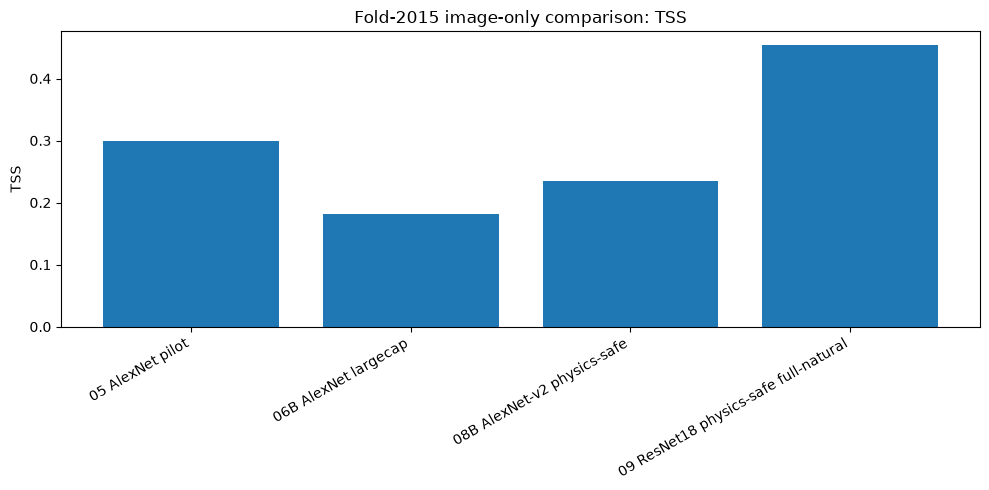

Saved results/figures/aia_fold2015_image_comparison_tss.png


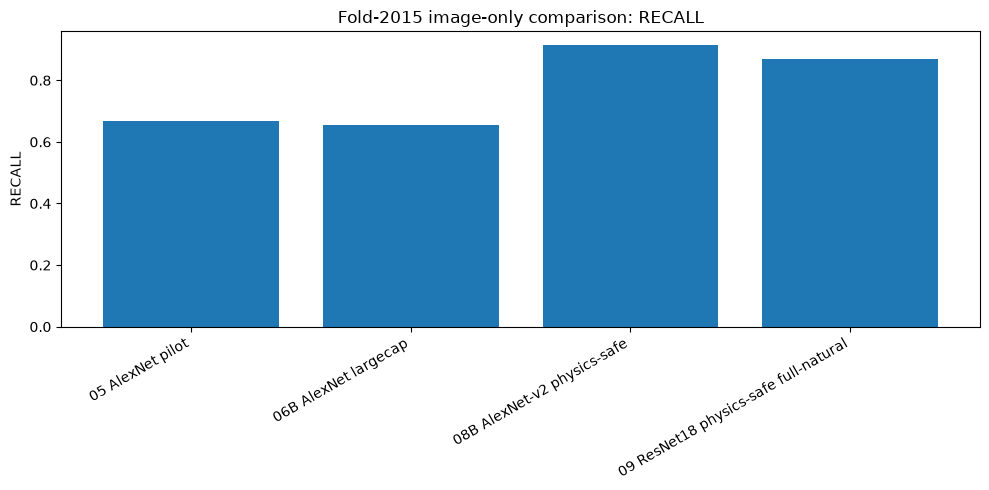

Saved results/figures/aia_fold2015_image_comparison_recall.png


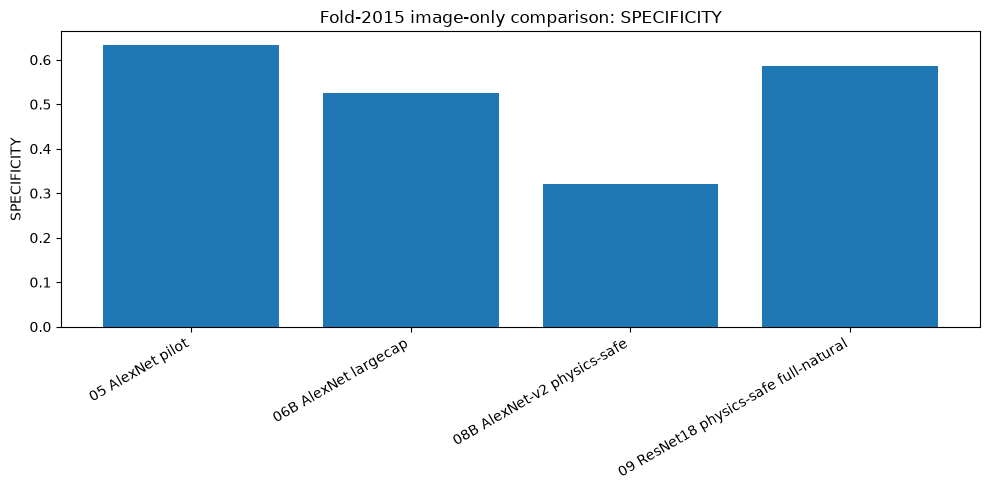

Saved results/figures/aia_fold2015_image_comparison_specificity.png


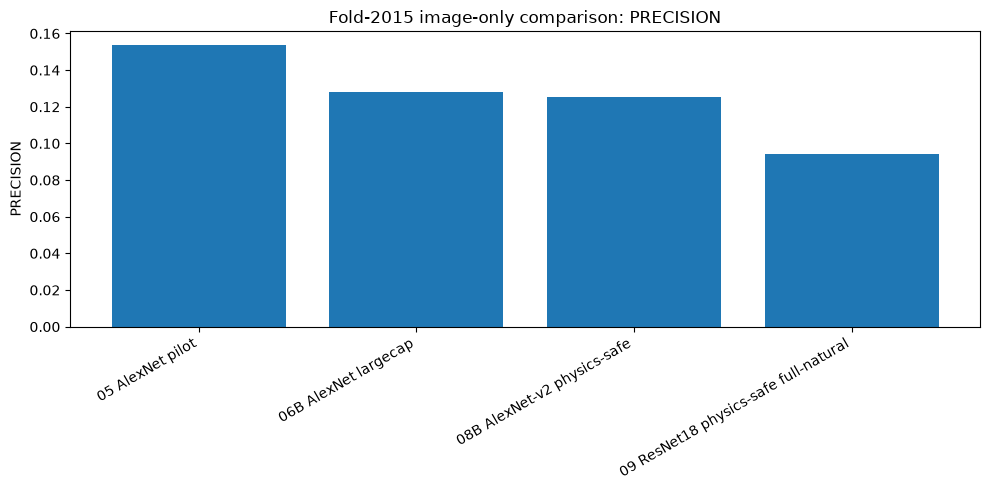

Saved results/figures/aia_fold2015_image_comparison_precision.png


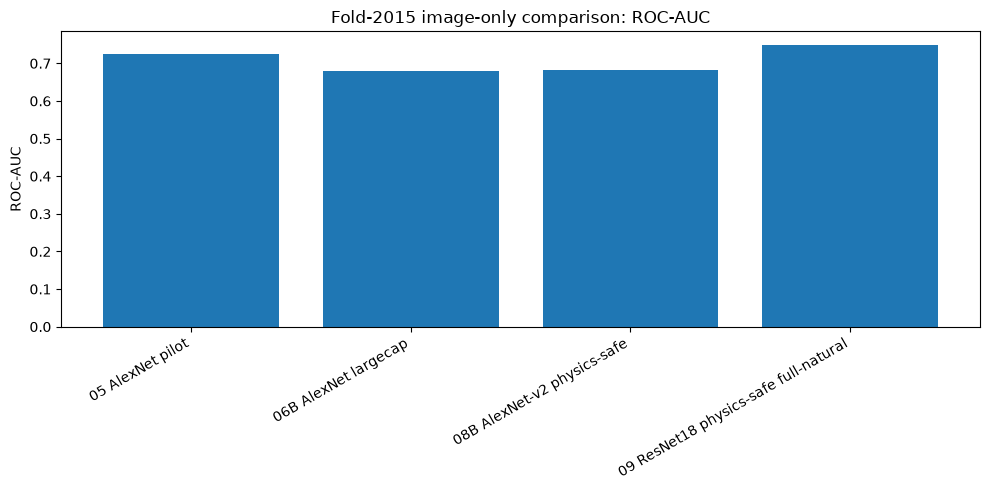

Saved results/figures/aia_fold2015_image_comparison_roc_auc.png


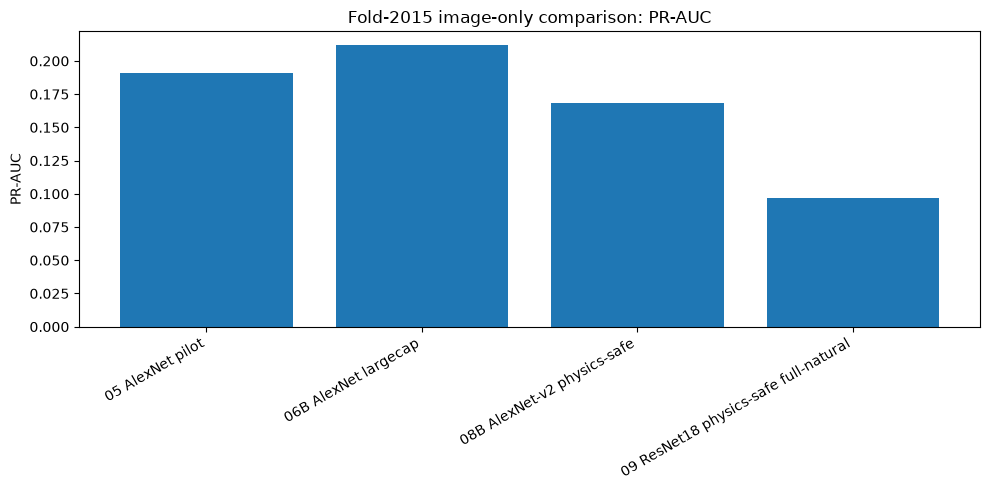

Saved results/figures/aia_fold2015_image_comparison_pr_auc.png


In [7]:
import matplotlib.pyplot as plt

plot_df = df_save[pd.to_numeric(df_save["tss"], errors="coerce").notna()].reset_index(drop=True)

for metric in ["tss", "recall", "specificity", "precision", "roc_auc", "pr_auc"]:
    vals = pd.to_numeric(plot_df[metric], errors="coerce")
    labels = plot_df["run"].tolist()
    plt.figure(figsize=(10, 5))
    plt.bar(labels, vals)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric.upper().replace("_", "-"))
    plt.title(f"Fold-2015 image-only comparison: {metric.upper().replace('_', '-')}")
    plt.tight_layout()
    fig_path = FIG_DIR / f"aia_fold2015_image_comparison_{metric}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved", fig_path.relative_to(ROOT))

## Interpretation draft

In [8]:
resnet = df_save[df_save["run"].str.contains("ResNet18", case=False, na=False)].iloc[0]
best_tss = df_save.loc[pd.to_numeric(df_save["tss"], errors="coerce").idxmax()]

interpretation = f'''# Interpretation: Fold-2015 Image-Only Baselines

The fold-2015 image-only experiments show a clear progression from capped AlexNet engineering baselines toward a more scientifically defensible full-natural benchmark.

The strongest official TSS in this comparison is from **{best_tss["run"]}**, with **TSS={best_tss["tss"]:.4f}**, **Recall={best_tss["recall"]:.4f}**, **Specificity={best_tss["specificity"]:.4f}**, and **ROC-AUC={best_tss["roc_auc"]:.4f}**.

The full-natural ResNet18 run used **{int(resnet["train_rows"])} training samples**, **{int(resnet["val_rows"])} validation samples**, and **{int(resnet["test_rows"])} test samples**, with **{int(resnet["test_positives"])} positives** and **{int(resnet["test_negatives"])} negatives** in the 2015 test set. At the validation-selected threshold of **{resnet["threshold"]:.4f}**, it achieved **TSS={resnet["tss"]:.4f}**, **HSS={resnet["hss"]:.4f}**, **Recall={resnet["recall"]:.4f}**, and **Precision={resnet["precision"]:.4f}**.

The low precision should be interpreted in the context of severe natural class imbalance. The result indicates high event sensitivity but many false alarms, which is a known operational trade-off in rare-event space-weather forecasting. Importantly, the threshold was selected on validation data and then applied unchanged to the test set.

Overall, AlexNet-style models are retained as useful baselines and pipeline validation experiments, but the physics-safe full-natural ResNet18 result is the current strongest image-only benchmark for fold-2015.
'''

summary_path = METRICS_DIR / "aia_fold2015_image_baseline_comparison_interpretation.md"
summary_path.write_text(interpretation)
display(Markdown(interpretation))
print("Saved", summary_path.relative_to(ROOT))

# Interpretation: Fold-2015 Image-Only Baselines

The fold-2015 image-only experiments show a clear progression from capped AlexNet engineering baselines toward a more scientifically defensible full-natural benchmark.

The strongest official TSS in this comparison is from **09 ResNet18 physics-safe full-natural**, with **TSS=0.4534**, **Recall=0.8682**, **Specificity=0.5852**, and **ROC-AUC=0.7477**.

The full-natural ResNet18 run used **38329 training samples**, **11627 validation samples**, and **11236 test samples**, with **531 positives** and **10705 negatives** in the 2015 test set. At the validation-selected threshold of **0.2050**, it achieved **TSS=0.4534**, **HSS=0.0923**, **Recall=0.8682**, and **Precision=0.0941**.

The low precision should be interpreted in the context of severe natural class imbalance. The result indicates high event sensitivity but many false alarms, which is a known operational trade-off in rare-event space-weather forecasting. Importantly, the threshold was selected on validation data and then applied unchanged to the test set.

Overall, AlexNet-style models are retained as useful baselines and pipeline validation experiments, but the physics-safe full-natural ResNet18 result is the current strongest image-only benchmark for fold-2015.


Saved results/metrics/aia_fold2015_image_baseline_comparison_interpretation.md


## Backup and commit commands

After running this notebook on the VM:

```bash
cd ~/solar_flare_aia

gcloud storage cp \
  results/metrics/aia_fold2015_image_baseline_comparison* \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/fold2015_image_comparison/

gcloud storage cp \
  results/figures/aia_fold2015_image_comparison_*.png \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/fold2015_image_comparison/

gcloud storage cp \
  notebooks/training/10_aia_fold2015_image_baseline_comparison.ipynb \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/fold2015_image_comparison/

gcloud storage cp \
  notebooks/executed/10_aia_fold2015_image_baseline_comparison_EXECUTED.ipynb \
  gs://suryabench-sharp-pipeline-bamidele/aia_cnn_baselines/fold2015_image_comparison/
```

Then commit:

```bash
git add notebooks/training/10_aia_fold2015_image_baseline_comparison.ipynb
git add notebooks/executed/10_aia_fold2015_image_baseline_comparison_EXECUTED.ipynb
git add results/metrics/aia_fold2015_image_baseline_comparison*
git add results/figures/aia_fold2015_image_comparison_*.png
git commit -m "Add fold-2015 image baseline comparison"
git push
```